## 1. Person Identification using the embeddings

In [3]:
# Load libraries
import os
import sys

PROJECT_PATH = os.path.dirname(os.getcwd())
sys.path.insert(0, os.path.dirname(os.getcwd()))

import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import SVC
from torch.utils.data import ConcatDataset, DataLoader
from tqdm import tqdm

from datasets.dataset import PatientDataset
import utils.parse as parser
from models.cnn import SimpleCNN

In [4]:
# Load model
pretrained_model = os.path.join(PROJECT_PATH, "pretrained_models/cnn_contrastive_01.pt")
model = SimpleCNN(channel_sequence=[1, 32, 64, 128, 256])
model.load_state_dict(torch.load(pretrained_model))

<All keys matched successfully>

In [5]:
# Config for extracting embeddings
train_embedding_config = {
    "feature_mapping": {
        "hrm": ["heartRate_nanmean", "rRInterval_nanmean", "rRInterval_rmssd", "rRInterval_sdnn"],
        "gyr": ["gyr_mean", "gyr_std", "gyr_delta_mean", "gyr_delta_std"],
        "linacc": ["acc_mean", "acc_std", "acc_delta_std"],
        "sleep": ["interval_sleep", "aggr_sleep", "n_sleep"],
        "time": ["cos_t", "sin_t"]
    },
    "track_id": 1,
    "patients": [1, 2, 3, 4, 5, 6, 7, 8, 9],
    "batch_size": 256,
    "upsampling_size": 60,
    "window_size": 32,
    "file_format": ".csv",
    "num_workers": 8
}

In [6]:
def get_embeddings(model, config):
    data = []
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    X_train, y_train, X_test, y_test, = [], [], [], []
    for p in config['patients']:
        d_set = PatientDataset(track_id=config['track_id'],
                               patient_id=p,
                               mode="train",
                               window_size=config['window_size'],
                               extension=config['file_format'],
                               feature_mapping=config['feature_mapping'])
        val_d_set = PatientDataset(track_id=config['track_id'],
                                   patient_id=p,
                                   mode="val",
                                   window_size=config['window_size'],
                                   extension=config['file_format'],
                                   feature_mapping=config['feature_mapping'])
        d_set._cal_statistics()
        val_d_set.mean, val_d_set.std = d_set.mean, d_set.std
        d_set._upsample_data(upsample_size=config['upsampling_size'])
        val_d_set._upsample_data(upsample_size=config['upsampling_size'])
        train_dloader = DataLoader(d_set,
                                   batch_size=config['batch_size'],
                                   shuffle=False,
                                   num_workers=config['num_workers'])
        val_dloader = DataLoader(val_d_set,
                                 batch_size=config['batch_size'],
                                 shuffle=False,
                                 num_workers=config['num_workers'])
        model.eval()
        with torch.no_grad():
            for d in tqdm(train_dloader, desc=f"Extracting train embeddings for patient {p}", total=len(train_dloader)):
                features, labels = d['features'], d['patient_id'] - 1
                features = features.to(device)
                embeddings = model(features)
                X_train.append(embeddings.cpu().numpy())
                y_train.append(labels.numpy())

            for d in tqdm(val_dloader, desc=f"Extracting val embeddings for patient {p}", total=len(val_dloader)):
                features, labels = d['features'], d['patient_id'] - 1
                features = features.to(device)
                embeddings = model(features)
                X_test.append(embeddings.cpu().numpy())
                y_test.append(labels.numpy())

    X_train, y_train = np.concatenate(X_train, axis=0), np.concatenate(y_train)
    X_test, y_test = np.concatenate(X_test, axis=0), np.concatenate(y_test)

    return {"X_train": X_train, "y_train": y_train, "X_test": X_test, "y_test": y_test}

In [7]:
# Get embeddings
d = get_embeddings(model=model, config=train_embedding_config)

Extracting val embeddings for patient 9: 100%|██████████| 15/15 [00:01<00:00, 14.96it/s]


In [8]:
print(d['X_train'].shape)
print(d['y_train'].shape)

(93480, 256)
(93480,)


In [9]:
print(d['X_test'].shape)
print(d['y_test'].shape)

(42540, 256)
(42540,)


In [10]:
# Fit SVM and evaluate
svm = SVC(kernel='rbf', degree=3)
svm.fit(d['X_train'], d['y_train'])

SVC()

In [11]:
from sklearn.metrics import classification_report

In [12]:
preds = svm.predict(d['X_test'])
print(classification_report(y_true=d['y_test'], y_pred=preds))

              precision    recall  f1-score   support

           0       0.99      0.92      0.95      3000
           1       0.98      0.99      0.98      6000
           2       0.97      0.98      0.98      5340
           3       0.97      1.00      0.99      5160
           4       0.99      1.00      0.99      5280
           5       0.97      0.98      0.97      4140
           6       1.00      1.00      1.00      5100
           7       0.98      0.98      0.98      4740
           8       0.97      0.93      0.95      3780

    accuracy                           0.98     42540
   macro avg       0.98      0.98      0.98     42540
weighted avg       0.98      0.98      0.98     42540



## 2. 2D Visualization of embeddings

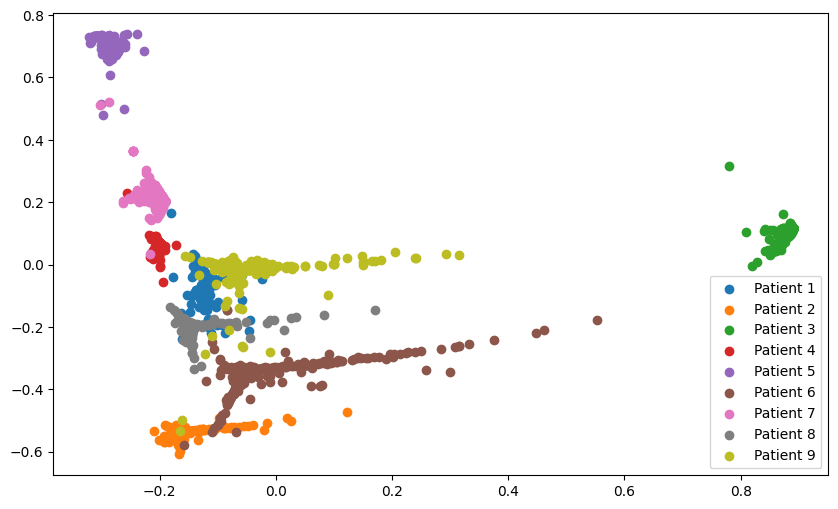

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
num_samples = 500
X_PCA = pca.fit_transform(d['X_train'])

fig, ax = plt.subplots(figsize=(10, 6))
for p in range(9):
    XP = X_PCA[d['y_train'] == p]
    indices = np.random.choice(a=XP.shape[0], size=num_samples, replace=False)
    x, y = XP[indices, 0], XP[indices, 1]
    ax.scatter(x=x, y=y, label=f"Patient {p+1}")
plt.legend()
plt.show()

## 3. Anomaly Detection

In [14]:
# Fit OneClass SVMs on training data for each patient
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

svms = {}
for patient_id in range(9):
    svm = OneClassSVM()
    X_train, y_train = d['X_train'], d['y_train']
    X_train = X_train[y_train == patient_id]

    print(f'{X_train.shape[0]} number of samples for patient {patient_id}')

    svm.fit(X_train)
    svms[f'patient_{patient_id}'] = svm

8880 number of samples for patient 0


10860 number of samples for patient 1
13740 number of samples for patient 2
10140 number of samples for patient 3
11340 number of samples for patient 4
10620 number of samples for patient 5
9660 number of samples for patient 6
10320 number of samples for patient 7
7920 number of samples for patient 8


In [15]:
test_config = {
    "feature_mapping": {
        "hrm": ["heartRate_nanmean", "rRInterval_nanmean", "rRInterval_rmssd", "rRInterval_sdnn"],
        "gyr": ["gyr_mean", "gyr_std", "gyr_delta_mean", "gyr_delta_std"],
        "linacc": ["acc_mean", "acc_std", "acc_delta_std"],
        "sleep": ["interval_sleep", "aggr_sleep", "n_sleep"],
        "time": ["cos_t", "sin_t"]
    },
    "track_id": 1,
    "patients": [1, 2, 3, 4, 5, 6, 7, 8, 9],
    "batch_size": 256,
    "upsampling_size": 120,
    "window_size": 32,
    "file_format": ".csv",
    "num_workers": 8
}

In [16]:
import pandas as pd

### 3.1 Custom Metric

In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dfs = {}
for patient_id in range(1, 10):
    train_dset = PatientDataset(track_id=test_config['track_id'],
                                patient_id=patient_id,
                                mode="train",
                                window_size=test_config['window_size'],
                                extension=test_config['file_format'],
                                feature_mapping=test_config['feature_mapping'])
    val_dset = PatientDataset(track_id=test_config['track_id'],
                              patient_id=patient_id,
                              mode="val",
                              window_size=test_config['window_size'],
                              extension=test_config['file_format'],
                              feature_mapping=test_config['feature_mapping'])
    train_dset._cal_statistics()
    val_dset.mean, val_dset.std = train_dset.mean, train_dset.std
    val_dset._upsample_data(upsample_size=test_config['upsampling_size'])

    df_info = {"split": [], "day_index": [], "label": [], "distance_from_hp": [], "prediction": []}
    val_dloader = DataLoader(dataset=val_dset,
                             batch_size=test_config['batch_size'],
                             shuffle=False,
                             num_workers=test_config['num_workers'])
    model.eval()
    with torch.no_grad():
        for res in val_dloader:
            features, labels = res['features'], res['label']
            features = features.to(device)
            embeddings = model(features)
            embeddings = embeddings.cpu().numpy()

            svm = svms[f'patient_{patient_id-1}']
            distance_from_hp = svm.decision_function(embeddings)
            preds = svm.predict(embeddings)

            df_info['split'].append(res['split'])
            df_info['day_index'].append(res['day_index'].numpy())
            df_info['label'].append(res['label'].numpy())
            df_info['distance_from_hp'].append(distance_from_hp)
            df_info['prediction'].append(preds)


    for k, v in df_info.items():
        df_info[k] = np.concatenate(v)

    dfs[f'patient_{patient_id-1}'] = pd.DataFrame(df_info)

In [18]:
dfs.keys()

dict_keys(['patient_0', 'patient_1', 'patient_2', 'patient_3', 'patient_4', 'patient_5', 'patient_6', 'patient_7', 'patient_8'])

In [19]:
from utils.util_funcs import svm_score, fill_predictions, calculate_roc_pr_auc, apply_postprocessing_filter

In [20]:
dfs['patient_0'].columns

Index(['split', 'day_index', 'label', 'distance_from_hp', 'prediction'], dtype='object')

In [21]:
final_dfs = {}

for patient, df in dfs.items():
    final_dfs[patient] = []
    id = int(patient.split("_")[1]) + 1
    splits = df['split'].unique()

    for split in splits:
        anomaly_scores, split_list, days_list = [], [], []
        df_split = df[df['split'] == split]
        days = df_split['day_index'].unique()
        for day_index in days:
            df_day = df_split[df_split['day_index'] == day_index]
            distances = df_day['distance_from_hp']
            preds = df_day['prediction']
            anomaly_scores.append(svm_score(preds=preds, dist_from_hp=distances))
            split_list.append(split)
            days_list.append(day_index)
        split_df = fill_predictions(track_id=1,
                                    patient_id=id,
                                    anomaly_scores=anomaly_scores,
                                    split=split,
                                    days=days_list)
        # Apply filters
        split_df['anomaly_scores'] = apply_postprocessing_filter(anomaly_scores=split_df['anomaly_scores'],
                                                                 filter_type="median",
                                                                 filter_size=5)
        split_df['anomaly_scores'] = apply_postprocessing_filter(anomaly_scores=split_df['anomaly_scores'],
                                                                 filter_type="median",
                                                                 filter_size=13)
        final_dfs[patient].append(split_df)
    final_dfs[patient] = pd.concat(final_dfs[patient], axis=0)

In [22]:
patient_results = {}

for patient, df in final_dfs.items():
    patient_results[patient] = calculate_roc_pr_auc(anomaly_scores=df['anomaly_scores'], labels=df['relapse'])

In [23]:
patient_results

{'patient_0': {'ROC AUC': 0.5133928571428572, 'PR AUC': 0.6908041033780915},
 'patient_1': {'ROC AUC': 0.5685369318181819, 'PR AUC': 0.7153878889887727},
 'patient_2': {'ROC AUC': 0.8586538461538461, 'PR AUC': 0.8633262593983979},
 'patient_3': {'ROC AUC': 0.805128205128205, 'PR AUC': 0.5198585231193926},
 'patient_4': {'ROC AUC': 0.34171597633136097, 'PR AUC': 0.5096443873465829},
 'patient_5': {'ROC AUC': 0.6028490028490028, 'PR AUC': 0.7175856998437644},
 'patient_6': {'ROC AUC': 0.5160818713450293, 'PR AUC': 0.586443052297946},
 'patient_7': {'ROC AUC': 0.196031746031746, 'PR AUC': 0.0681076683793953},
 'patient_8': {'ROC AUC': 0.6881147540983606, 'PR AUC': 0.5225447246136902}}

In [24]:
roc, pr = [], []
for p, v in patient_results.items():
    roc.append(v['ROC AUC'])
    pr.append(v['PR AUC'])

print(f"ROC AUC: {np.mean(roc)}\nPR AUC: {np.mean(pr)}\nTotal: {(np.mean(roc) + np.mean(pr)) / 2}")

ROC AUC: 0.5656116878776211
PR AUC: 0.5770780341517815
Total: 0.5713448610147013


### 3.2 Anomaly score with Ratio

In [25]:
dfs['patient_0'].columns

Index(['split', 'day_index', 'label', 'distance_from_hp', 'prediction'], dtype='object')

In [26]:
final_dfs = {}

for patient, df in dfs.items():
    final_dfs[patient] = []
    id = int(patient.split("_")[1]) + 1
    splits = df['split'].unique()
    for split in splits:
        anomaly_scores, split_list, days_list = [], [], []
        df_split = df[df['split'] == split]
        days = df_split['day_index'].unique()
        for day in days:
            df_day = df_split[df_split['day_index'] == day]
            split_list.append(split)
            days_list.append(day)
            anomaly_scores.append((df_day[df_day['prediction'] == -1]).shape[0] / len(df_day))

        split_df = fill_predictions(track_id=1,
                            patient_id=id,
                            anomaly_scores=anomaly_scores,
                            split=split,
                            days=days_list)
        # Apply filters
        split_df['anomaly_scores'] = apply_postprocessing_filter(anomaly_scores=split_df['anomaly_scores'],
                                                                 filter_type="median",
                                                                 filter_size=5)
        split_df['anomaly_scores'] = apply_postprocessing_filter(anomaly_scores=split_df['anomaly_scores'],
                                                                 filter_type="median",
                                                                 filter_size=13)
        final_dfs[patient].append(split_df)
    final_dfs[patient] = pd.concat(final_dfs[patient], axis=0)

In [27]:
patient_results = {}

for patient, df in final_dfs.items():
    patient_results[patient] = calculate_roc_pr_auc(anomaly_scores=df['anomaly_scores'], labels=df['relapse'])

In [28]:
patient_results

{'patient_0': {'ROC AUC': 0.017857142857142856, 'PR AUC': 0.27066231358673976},
 'patient_1': {'ROC AUC': 0.3380681818181818, 'PR AUC': 0.3902172027617732},
 'patient_2': {'ROC AUC': 0.9487980769230769, 'PR AUC': 0.9611254617367246},
 'patient_3': {'ROC AUC': 0.7752136752136751, 'PR AUC': 0.2604086229086229},
 'patient_4': {'ROC AUC': 0.36094674556213013, 'PR AUC': 0.3345235676618009},
 'patient_5': {'ROC AUC': 0.5435897435897437, 'PR AUC': 0.5990947981756805},
 'patient_6': {'ROC AUC': 0.7627923976608187, 'PR AUC': 0.7342086723586909},
 'patient_7': {'ROC AUC': 0.22142857142857145, 'PR AUC': 0.07024145033866643},
 'patient_8': {'ROC AUC': 0.4877049180327869, 'PR AUC': 0.21179733147678798}}

In [29]:
roc, pr = [], []
for p, v in patient_results.items():
    roc.append(v['ROC AUC'])
    pr.append(v['PR AUC'])

print(f"ROC AUC: {np.mean(roc)}\nPR AUC: {np.mean(pr)}\nTotal: {(np.mean(roc) + np.mean(pr)) / 2}")

ROC AUC: 0.49515549478734755
PR AUC: 0.42580882455616526
Total: 0.46048215967175643
